# Visualizing Our Final Curated SeisBench Dataset

Welcome! In this notebook, we are going to explore and visualize the final seismic dataset we have curated. 
Think of this dataset as a highly organized digital library of earthquakes (and icequakes!). We've packaged it into a format called **SeisBench**, which is specially designed to make training Machine Learning models very easy.

Our goal here is to:
1. **Load** our SeisBench dataset.
2. **Examine** the metadata (the "tags" or "labels" that describe each seismic wave).
3. **Visualize** the actual seismic waves (waveforms) along with the exact moments the P-waves and S-waves arrive.

Let's get started!

In [1]:
import os
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seisbench.data as sbd

/home/hongyuxiao/miniconda3/envs/TL/lib/python3.12/site-packages/seisbench/__init__.py:7: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


## 1. Loading the Dataset

Our data is saved in a folder named `final_curated_seisbench_data`. This folder contains two important files:
- `waveforms.hdf5`: A high-performance file storing the actual squiggly lines (seismic waves).
- `metadata.csv`: A spreadsheet containing information about each wave (like which station recorded it, and when the earthquake happened).

We use `sbd.WaveformDataset` to load both of these together seamlessly.

In [2]:
# Path to the final dataset directory
dataset_path = 'final_curated_seisbench_data'

if not os.path.exists(dataset_path):
    print(f"Error: Dataset path '{dataset_path}' not found. Make sure you ran the previous scripts!")
else:
    print(f"Loading SeisBench dataset from '{dataset_path}'...")
    # Load the dataset into memory
    dataset = sbd.WaveformDataset(dataset_path)
    print("Dataset loaded successfully!")

2026-04-24 21:49:08,547 | seisbench | WARNING | Component order not specified, defaulting to 'ZNE'.


Loading SeisBench dataset from 'final_curated_seisbench_data'...
Dataset loaded successfully!


## 2. Exploring the Metadata

Metadata is data *about* data. For each seismic recording, we have metadata telling us its sampling rate (how many data points per second), the station code, and importantly, the **arrival times** of the P-waves and S-waves. These arrival times act as the "answer key" for our future AI models.

Let's see what columns are available and look at the first few rows.

In [3]:
print("DATASET METADATA SUMMARY")
print("="*50)
print(f"Total number of traces (earthquake recordings): {len(dataset)}\n")

# Print out all the available columns in our metadata
print("Available metadata columns:")
for col in dataset.metadata.columns:
    print(f"  - {col}")
    
# Display the first 5 rows to see what the data actually looks like
print("\nFirst 15 rows of metadata:")
with pd.option_context('display.max_columns', None, 'display.width', 1000):
    display(dataset.metadata.head(15))

DATASET METADATA SUMMARY
Total number of traces (earthquake recordings): 370

Available metadata columns:
  - index
  - trace_name_original
  - station_network_code
  - station_code
  - trace_channel
  - trace_sampling_rate_hz
  - trace_npts
  - trace_start_time
  - source_id
  - split
  - trace_p_arrival_sample
  - trace_p_status
  - trace_s_arrival_sample
  - trace_s_status
  - trace_name
  - trace_chunk
  - trace_component_order

First 15 rows of metadata:


,index,trace_name_original,station_network_code,station_code,trace_channel,trace_sampling_rate_hz,trace_npts,trace_start_time,source_id,split,trace_p_arrival_sample,trace_p_status,trace_s_arrival_sample,trace_s_status,trace_name,trace_chunk,trace_component_order
0,0,2E.BAUM.2020-04-18T20:18:52.063274Z,2E,BAUM,HH,200.0,2001,2020-04-18T20:18:52.063274Z,5013ddd9-af2f-4635-b700-f665ba591b0c,test,1000.0,manual,1182.0,manual,"bucket0$0,:3,:2001",,ZNE
1,1,2E.BAUM.2020-04-19T23:39:31.650999Z,2E,BAUM,HH,200.0,2001,2020-04-19T23:39:31.650999Z,9f5c524d-7438-4351-aebb-7207c78c0c1f,train,1000.0,manual,1175.0,manual,"bucket1$0,:3,:2001",,ZNE
2,2,2E.BAUM.2020-05-02T04:32:22.574681Z,2E,BAUM,HH,200.0,2001,2020-05-02T04:32:22.574681Z,ebc68982-9402-4bef-99e6-3232a0dea80c,train,1000.0,manual,1180.0,manual,"bucket1$1,:3,:2001",,ZNE
3,3,2E.DEEJ.2020-07-17T03:23:39.598190Z,2E,DEEJ,HH,200.0,2001,2020-07-17T03:23:39.598190Z,313770e9-b8c1-458f-a599-4bab3f580f80,test,1000.0,manual,NaN,NaN,"bucket0$1,:3,:2001",,ZNE
4,4,2E.DEEJ.2020-07-25T02:57:59.654901Z,2E,DEEJ,HH,200.0,2001,2020-07-25T02:57:59.654901Z,46edd12a-7154-4527-a84a-280fbfbd1c65,train,NaN,NaN,1000.0,manual,"bucket1$2,:3,:2001",,ZNE
5,5,2E.DEEJ.2020-07-25T10:36:49.780947Z,2E,DEEJ,HH,200.0,2001,2020-07-25T10:36:49.780947Z,913feee2-db39-43b7-baa4-ddd29769abc0,train,1000.0,manual,NaN,NaN,"bucket1$3,:3,:2001",,ZNE
6,6,2E.DEEJ.2020-07-28T21:04:21.905947Z,2E,DEEJ,HH,200.0,2001,2020-07-28T21:04:21.905947Z,eb23675c-17f7-4e53-8c0e-f365d6784080,train,1000.0,manual,NaN,NaN,"bucket1$4,:3,:2001",,ZNE
7,7,2E.DEEJ.2020-07-29T12:07:42.640947Z,2E,DEEJ,HH,200.0,2001,2020-07-29T12:07:42.640947Z,17ad2106-1dc8-4247-ad6e-95316edb12ea,train,1000.0,manual,NaN,NaN,"bucket1$5,:3,:2001",,ZNE
8,8,2E.DEEJ.2020-08-14T00:14:21.269236Z,2E,DEEJ,HH,200.0,2001,2020-08-14T00:14:21.269236Z,2b2ab3b5-d7f6-4792-bc37-81a3a54c98b7,dev,NaN,NaN,1000.0,manual,"bucket2$0,:3,:2001",,ZNE
9,9,2E.DEEJ.2020-08-24T21:05:19.523756Z,2E,DEEJ,HH,200.0,2001,2020-08-24T21:05:19.523756Z,f0f4ccea-3118-48f2-ba03-e07e2bfc5d02,train,NaN,NaN,1000.0,manual,"bucket1$6,:3,:2001",,ZNE


## 3. Dataset Statistics

It's always good practice to get a high-level summary of our data. How many stations are we using? How many of our recordings actually have a P-wave or an S-wave labeled?

The code below calculates these statistics using `pandas` functions like `nunique()` (number of unique values) and `notna().sum()` (count of values that are not empty).

In [4]:
print("Dataset Summary:")
print(f"  Stations: {dataset.metadata['station_code'].nunique()}")
print(f"  Networks: {dataset.metadata['station_network_code'].nunique()}")

# Count how many traces have a P-wave arrival sample labeled
if 'trace_p_arrival_sample' in dataset.metadata.columns:
    print(f"  Traces with P-picks: {dataset.metadata['trace_p_arrival_sample'].notna().sum()}")
else:
    print("  Traces with P-picks: 0")
    
# Count how many traces have an S-wave arrival sample labeled
if 'trace_s_arrival_sample' in dataset.metadata.columns:
    print(f"  Traces with S-picks: {dataset.metadata['trace_s_arrival_sample'].notna().sum()}")
else:
    print("  Traces with S-picks: 0")

Dataset Summary:
  Stations: 13
  Networks: 1
  Traces with P-picks: 104
  Traces with S-picks: 295


## 4. Visualizing the Seismic Waves

Now for the fun part! We will visualize a few examples from our dataset.

A standard seismic station records ground motion in 3 dimensions:
1. **Z (Vertical):** Up and down motion.
2. **N (North):** North and south motion.
3. **E (East):** East and west motion.

In the loop below, we will:
- Grab the waveform data using `dataset.get_waveforms()`.
- Create a time axis (x-axis) by dividing the sample number by the sampling rate.
- Plot all three components (Z, N, E) on top of each other.
- Draw vertical dashed lines to indicate exactly when the P-wave (red) and S-wave (blue) arrived!


TRACE INFORMATION
Station:        2E.BAUM
Event ID:       5013ddd9-af2f-4635-b700-f665ba591b0c
Date/Time:      2020-04-18T20:18:52.063274Z
Sampling Rate:  200.0 Hz

Phase Arrivals:
  P-wave:       sample 1000 (5.00 s)
  S-wave:       sample 1182 (5.91 s)
  S-P time:     0.91 s


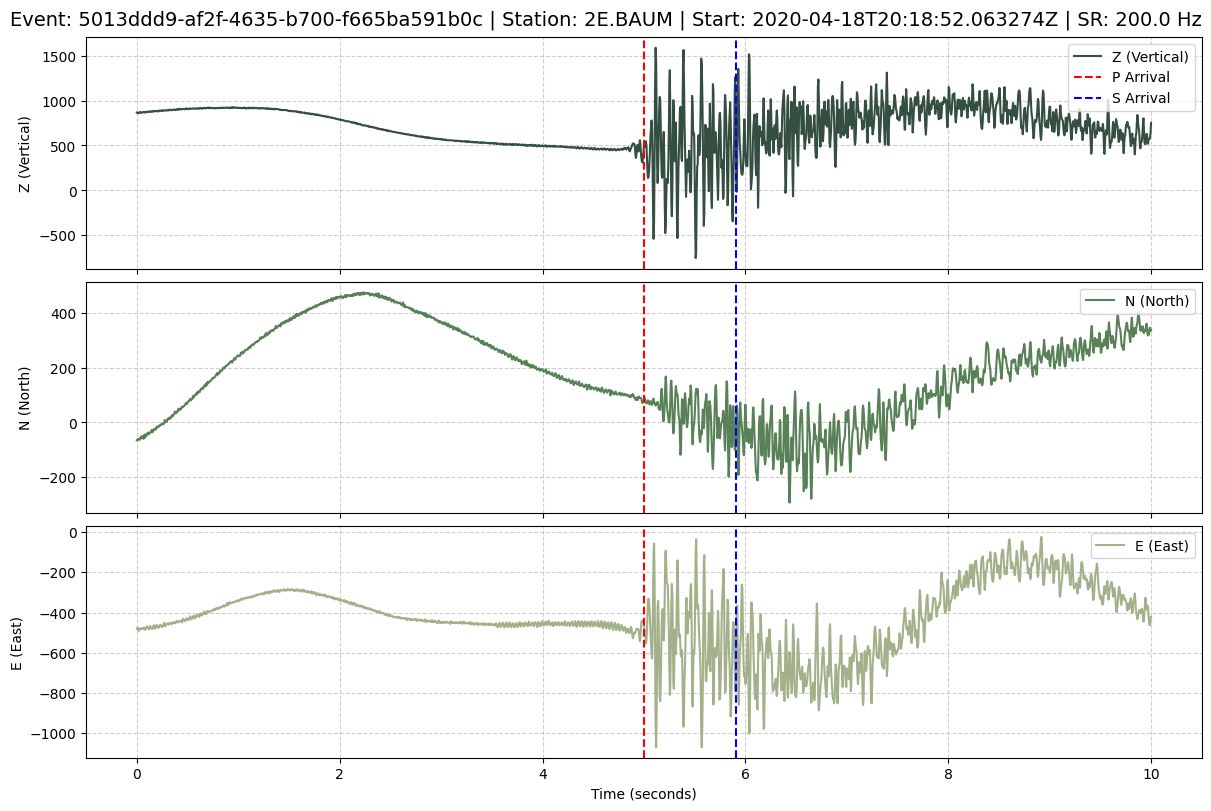


TRACE INFORMATION
Station:        2E.BAUM
Event ID:       9f5c524d-7438-4351-aebb-7207c78c0c1f
Date/Time:      2020-04-19T23:39:31.650999Z
Sampling Rate:  200.0 Hz

Phase Arrivals:
  P-wave:       sample 1000 (5.00 s)
  S-wave:       sample 1175 (5.88 s)
  S-P time:     0.88 s


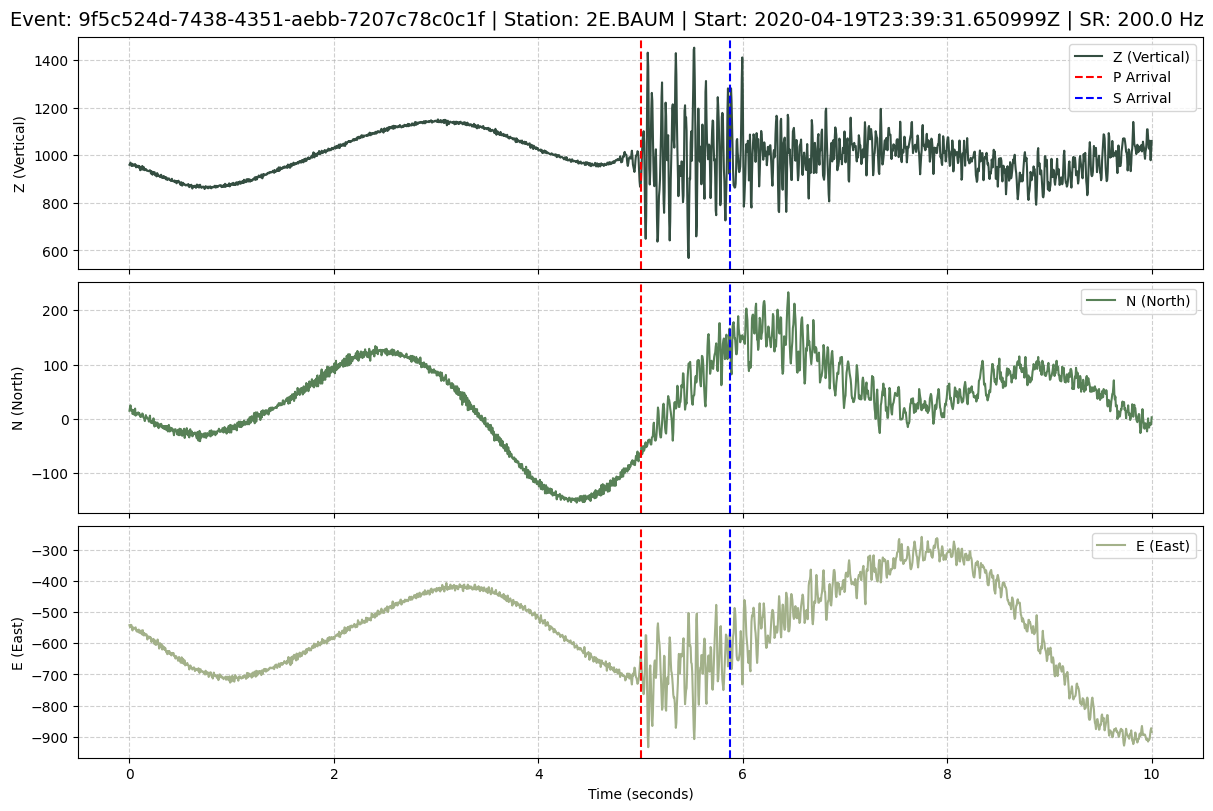


TRACE INFORMATION
Station:        2E.BAUM
Event ID:       ebc68982-9402-4bef-99e6-3232a0dea80c
Date/Time:      2020-05-02T04:32:22.574681Z
Sampling Rate:  200.0 Hz

Phase Arrivals:
  P-wave:       sample 1000 (5.00 s)
  S-wave:       sample 1180 (5.90 s)
  S-P time:     0.90 s


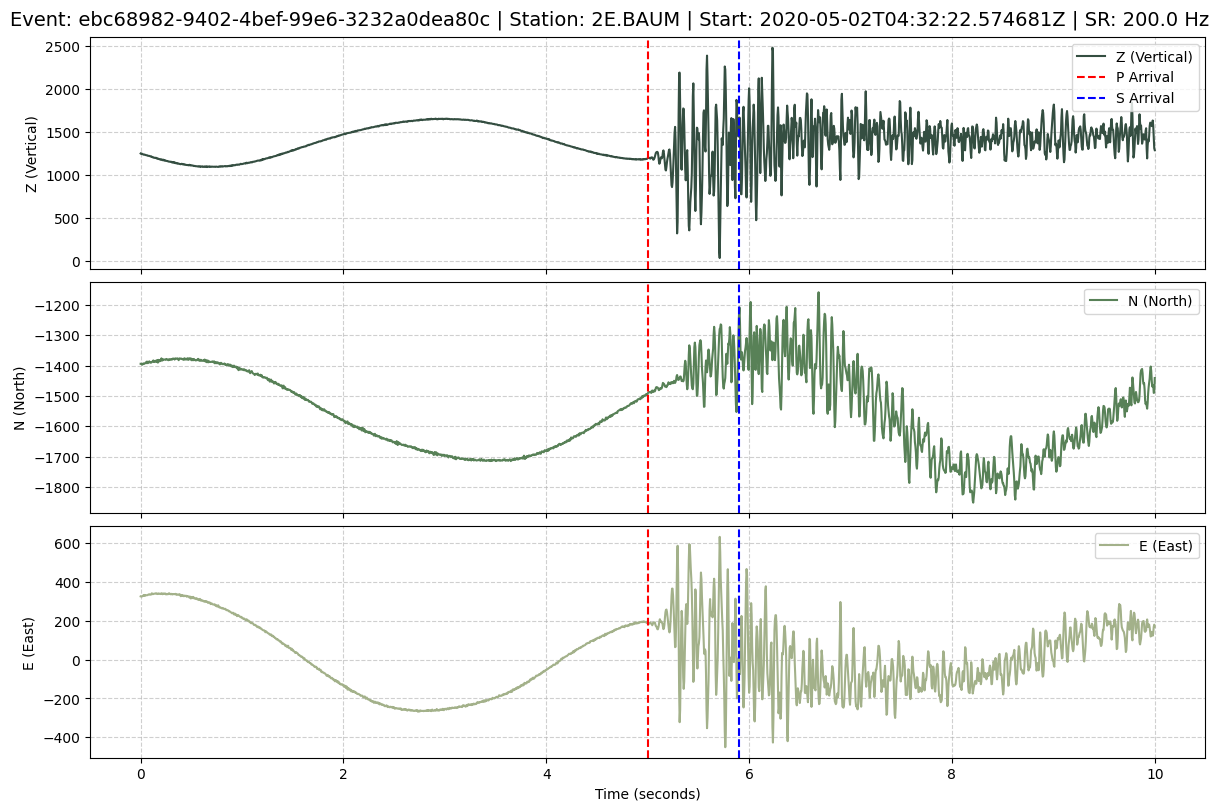

In [6]:
# Let's visualize the first 3 examples
num_examples = min(3, len(dataset))

# Define our beautiful Earth-tone colors for the Z, N, and E components
colors = ['#344e41', '#588157', '#a3b18a']
components = ['Z (Vertical)', 'N (North)', 'E (East)']

for trace_idx in range(num_examples):
    # 1. Get the actual waveform array and the metadata dictionary for this specific trace
    waveforms = dataset.get_waveforms(trace_idx)
    metadata = dataset.metadata.iloc[trace_idx]
    
    # 2. Extract sampling rate and number of points to build our time axis in seconds
    sr = metadata.get('trace_sampling_rate_hz', 100.0)
    npts = metadata.get('trace_npts', waveforms.shape[1])
    time_axis = np.arange(npts) / sr
    
    # 3. Extract identification info
    event_id = metadata.get('source_id', 'Unknown_Event')
    station_code = metadata.get('station_code', 'Unknown_Station')
    network_code = metadata.get('station_network_code', 'Unknown_Network')
    start_time = metadata.get('trace_start_time', 'Unknown_Time')
    
    # 4. Extract phase arrival samples and convert them to seconds
    p_sample = metadata.get('trace_p_arrival_sample', np.nan)
    s_sample = metadata.get('trace_s_arrival_sample', np.nan)
    
    p_time = p_sample / sr if pd.notna(p_sample) else np.nan
    s_time = s_sample / sr if pd.notna(s_sample) else np.nan
    sp_time = s_time - p_time if (pd.notna(p_time) and pd.notna(s_time)) else np.nan
    
    # --- Print Trace Information ---
    print(f"\n{'='*60}")
    print("TRACE INFORMATION")
    print(f"{'='*60}")
    print(f"Station:        {network_code}.{station_code}")
    print(f"Event ID:       {event_id}")
    print(f"Date/Time:      {start_time}")
    print(f"Sampling Rate:  {sr} Hz")
    print("\nPhase Arrivals:")
    if pd.notna(p_sample):
        print(f"  P-wave:       sample {int(p_sample)} ({p_time:.2f} s)")
    else:
        print("  P-wave:       None")
        
    if pd.notna(s_sample):
        print(f"  S-wave:       sample {int(s_sample)} ({s_time:.2f} s)")
    else:
        print("  S-wave:       None")
        
    if pd.notna(sp_time):
        print(f"  S-P time:     {sp_time:.2f} s")
    print(f"{'='*60}")
    
    # --- Plot the Waveform ---
    # Create a figure with 3 subplots (one for each component) sharing the same x-axis (time)
    fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True, constrained_layout=True)
    fig.suptitle(f"Event: {event_id} | Station: {network_code}.{station_code} | Start: {start_time} | SR: {sr} Hz", fontsize=14)
    
    # Zip groups axes, components, and colors together so we can loop through them simultaneously
    for i, (ax, comp, color) in enumerate(zip(axes, components, colors)):
        # Plot the squiggly line (waveform)
        ax.plot(time_axis, waveforms[i], color=color, linewidth=1.5, label=comp)
        
        # If we have a P-wave pick, draw a red dashed line
        if pd.notna(p_time):
            ax.axvline(x=p_time, color='red', linestyle='--', label='P Arrival' if i == 0 else "_nolegend_")
            
        # If we have an S-wave pick, draw a blue dashed line
        if pd.notna(s_time):
            ax.axvline(x=s_time, color='blue', linestyle='--', label='S Arrival' if i == 0 else "_nolegend_")
            
        ax.set_ylabel(f"{comp}", fontsize=10)
        ax.legend(loc='upper right')
        ax.grid(True, linestyle='--', alpha=0.6)
        
    axes[-1].set_xlabel("Time (seconds)")
    plt.show()

---
## Conclusion

Congratulations! You've successfully loaded and visualized your curated SeisBench dataset. By examining these plots, you can physically verify that our preprocessing was successful:
- The data has exactly 3 channels (Z, N, E).
- The phase picks (P and S) visually line up with the spikes in ground motion.

This dataset is now perfectly formatted and ready to be used to train Deep Learning models!